In [1]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

# Lotka-Volterra

In [2]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)
true_coeffs = generate_lotka_volterra_true_coefficients(1, 0.1, 1.5, 0.75)

dts = np.logspace(-2, 0, 11).tolist()
t_spans = sorted([(0, 5*i) for i in range(1, 10 + 1)], reverse=True)

t_span_test = (0, 50)

# if a parameter is a list, the experiment will be run for each combination of the parameters
# if a parameter is not a list, the same value will be used for all experiments
# the first list will be the rows and the second list will be the columns
experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span_test[0], t_span_test[1] + 0.01, 0.01),
    # define parameters that can be lists
    'x0': (10, 5),
    'noise_level': 0.01,
    't_eval_train': None, 'dt': dts, 't_span': t_spans, # we can use one of "t_eval_train" or ("dt" and "t_span")
    'threshold': 0.05,
    # define parameters that are used after the experiment
    'true_coeffs': true_coeffs
}

results = run_experiment(experiment_config)

rows are dt. there are 11 rows.
columns are t_span. there are 10 columns.
step 1 of 11


100%|██████████| 10/10 [00:09<00:00,  1.06it/s]


step 2 of 11


100%|██████████| 10/10 [00:07<00:00,  1.25it/s]


step 3 of 11


...

100%|██████████| 10/10 [00:13<00:00,  1.30s/it]


step 10 of 11


100%|██████████| 10/10 [00:04<00:00,  2.44it/s]


step 11 of 11


 60%|██████    | 6/10 [00:10<00:08,  2.24s/it]c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Repeated convergence failures (perhaps bad Jacobian or tolerances).
  solver._y, solver.t = integrator.run(
100%|██████████| 10/10 [00:17<00:00,  1.76s/it]


rows are dt. there are 11 rows.
columns are t_span. there are 10 columns.


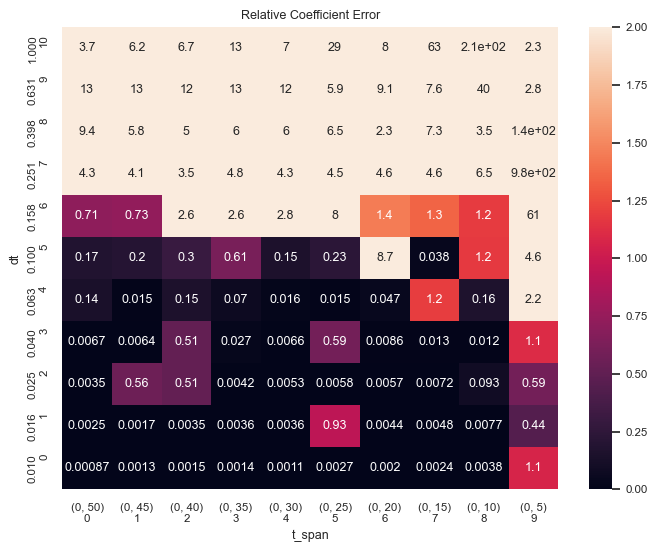

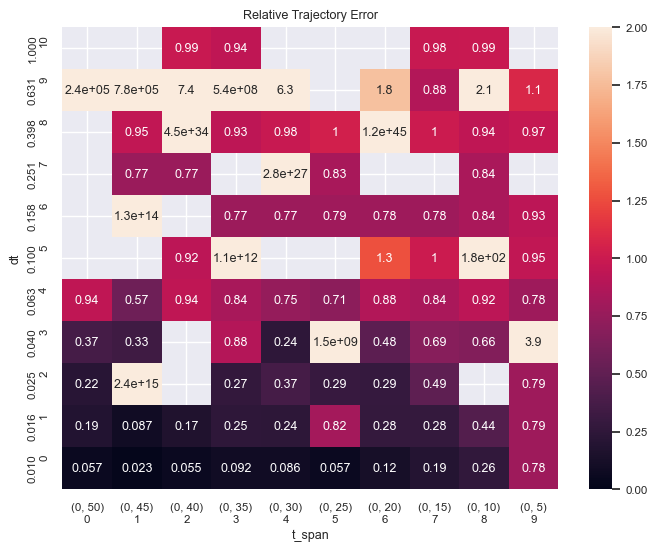

In [3]:
plot_heatmaps(experiment_config, results)

x0' = + 0.99656 x0 + -0.10003 x0 x1 
x1' = + -1.49276 x1 + 0.74856 x0 x1 


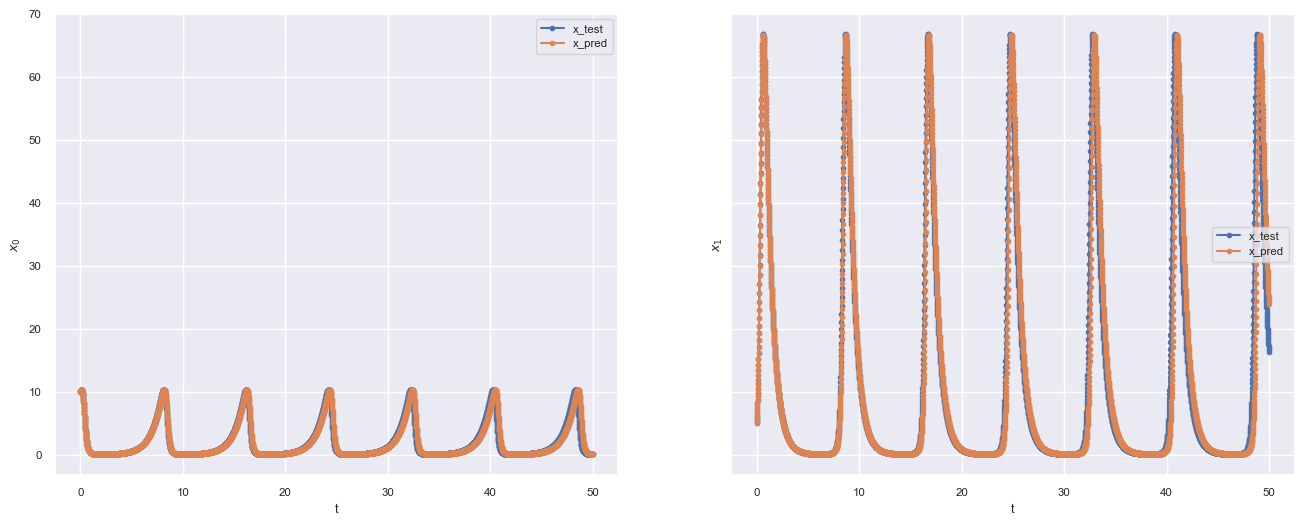

In [5]:
display_single_result(experiment_config, results, 3, 2)